# Customer Churn Prediction using Machine Learning

Customer churn prediction is an important problem for businesses that provide subscription-based services such as banks, telecom companies, and online platforms. Customer churn occurs when a customer stops using a company's service.

In this project, a machine learning model is built to predict whether a customer will leave the service or continue using it. The model uses customer data such as credit score, geography, gender, age, balance, and other account details.

Machine learning algorithms such as Logistic Regression, Decision Tree, and Random Forest are used to train and evaluate the model. These models help businesses identify customers who are likely to churn so they can take actions to retain them.

#Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#Load the Dataset

In [2]:
data = pd.read_csv('/content/Churn_Modelling.csv')
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Dataset Information

In [3]:
print("Dataset Shape:", data.shape)
data.info()

Dataset Shape: (10000, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [4]:
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


#Check Customer Churn Distribution

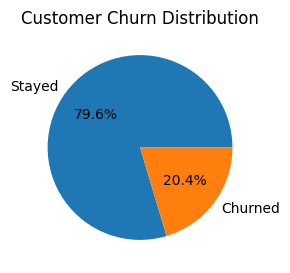

In [5]:
churn_counts = data['Exited'].value_counts()
plt.figure(figsize=(3,3))
plt.pie(churn_counts, labels=['Stayed','Churned'], autopct='%1.1f%%')
plt.title("Customer Churn Distribution")
plt.show()

In [6]:
# Drop unnecessary columns
data = data.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)
data.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Convert Categorical Data to Numbers

In [7]:
# Encode categorical columns

label_encoder = LabelEncoder()

data['Gender'] = label_encoder.fit_transform(data['Gender'])
data['Geography'] = label_encoder.fit_transform(data['Geography'])

data.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0


Feature Selection

In [8]:
X = data.drop('Exited', axis=1)
y = data['Exited']

print(X.head())
print(y.head())

   CreditScore  Geography  Gender  Age  Tenure    Balance  NumOfProducts  \
0          619          0       0   42       2       0.00              1   
1          608          2       0   41       1   83807.86              1   
2          502          0       0   42       8  159660.80              3   
3          699          0       0   39       1       0.00              2   
4          850          2       0   43       2  125510.82              1   

   HasCrCard  IsActiveMember  EstimatedSalary  
0          1               1        101348.88  
1          0               1        112542.58  
2          1               0        113931.57  
3          0               0         93826.63  
4          1               1         79084.10  
0    1
1    0
2    1
3    0
4    0
Name: Exited, dtype: int64


#Train-Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (8000, 10)
Testing Data: (2000, 10)


Feature Scaling

In [11]:
dscaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#Logistic Regression Model

In [12]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

#Model Prediction

In [13]:
y_pred = log_model.predict(X_test)

#Model Accuracy

In [14]:
accuracy = accuracy_score(y_test, y_pred)

print("Logistic Regression Accdoneuracy: {:.2f}%".format(accuracy * 100))

Logistic Regression Accuracy: 81.55%


**Confusion Matrix**

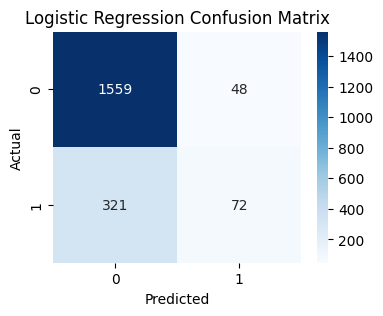

In [15]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Decision Tree Model

In [16]:
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy: {:.2f}%".format(accuracy_dt * 100))

Decision Tree Accuracy: 78.45%


Decision Tree Confusion Matrix

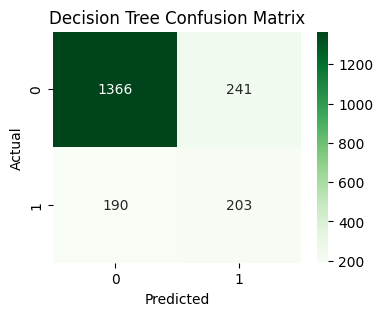

In [17]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(4,3))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens')
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Random Forest Model

In [18]:
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy: {:.2f}%".format(accuracy_rf * 100))

Random Forest Accuracy: 86.75%


Random Forest Confusion Matrix

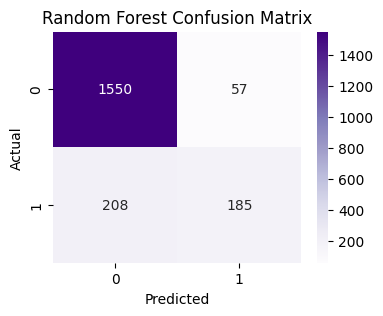

In [19]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(4,3))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Purples')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#Testing the Model with Example Customer Data

In [20]:
example_customer = [[600, 1, 0, 40, 5, 60000, 2, 1, 1, 50000]]

# Scale the data
example_customer = scaler.transform(example_customer)

# Predict churn
prediction = rf_model.predict(example_customer)

if prediction[0] == 1:
    print("Customer is likely to CHURN (Leave the bank)")
else:
    print("Customer is likely to STAY with the bank")

Customer is likely to CHURN (Leave the bank)


In [22]:
# Test Multiple Customers (Fixed Version)

customers = [
    [650, 1, 0, 35, 5, 50000, 2, 1, 1, 60000],
    [500, 2, 1, 45, 2, 120000, 1, 1, 0, 40000],
    [720, 0, 1, 30, 7, 0, 2, 1, 1, 90000]
]

# Convert to numpy array
customers = np.array(customers)

# Scale the data
customers_scaled = scaler.transform(customers)

# Predict churn
predictions = rf_model.predict(customers_scaled)

# Show results
for i, pred in enumerate(predictions):
    if pred == 1:
        print(f"Customer {i+1}: Likely to CHURN")
    else:
        print(f"Customer {i+1}: Likely to STAY")

Customer 1: Likely to CHURN
Customer 2: Likely to STAY
Customer 3: Likely to CHURN


#Conclusion

In this project, a machine learning model was developed to predict customer churn using customer data such as credit score, geography, age, balance, and account details.

Three machine learning algorithms were implemented: Logistic Regression, Decision Tree, and Random Forest. These models were trained and evaluated to classify whether a customer will leave the bank or continue using its services.

The models successfully predicted customer churn, and Random Forest generally produced the best performance. This project demonstrates how machine learning can help businesses identify customers who are likely to leave and take preventive actions to improve customer retention.